# Genome Rewiring – Optimisation Analysis

Evaluates the quality of Ledidi-optimised sequences across all pairs in a fold:

| Metric | Description |
|---|---|
| **Pearson R** | Correlation between predicted Hi-C map of optimised sequence and target map |
| **Edit count** | Number of base substitutions made by Ledidi |
| **Jaccard (init↔opt)** | Overlap of CTCF sites between initial and optimised sequence |
| **Jaccard (opt↔target)** | Overlap of CTCF sites between optimised and target sequence |

Dataset classes (`OriginalDataset`, `GenomicDataset`, `TriuMatrixDataset`) live in `utils/dataset_utils.py`.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from torch.utils.data import DataLoader

sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))
sys.path.insert(0, os.path.abspath("/home1/smaruj/akita_semifreddo/"))

from utils.model_utils import load_model
from utils.dataset_utils import SequenceDataset, TriuMatrixDataset

## Parameters

In [2]:
FOLD       = 0
BASE_DIR   = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/genome_rewiring"
MODEL_PATH = ("/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth")

COORDS_TSV      = f"{BASE_DIR}/genomic_optimization_fold{FOLD}.tsv"
INIT_SEQ_DIR    = f"{BASE_DIR}/ohe_X_fold{FOLD}/"
OPT_SEQ_DIR     = f"{BASE_DIR}/results_fold{FOLD}/"
TARGET_MAP_DIR  = f"{BASE_DIR}/genomic_targets_fold{FOLD}/"
JACCARD_TSV     = ("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/"
                   "optimizations/genome_rewiring/ctcf_jaccard_results_fold0.tsv")

PLOTS_DIR  = os.path.join(os.path.dirname(os.getcwd()), "plots")
BATCH_SIZE = 4

os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Plots → {PLOTS_DIR}")

Plots → /home1/smaruj/ledidi_akita/optimizations/genome_rewiring/plots


## Load Model and Data

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = load_model(MODEL_PATH, device)

df = pd.read_csv(COORDS_TSV, sep="\t")
print(f"Loaded {len(df)} sequence pairs")
df.head()

Device: cuda:0
Loaded 725 sequence pairs


,chrom,start,end,fold,target_chrom,target_start,target_end,last_accepted_step
0,chr5,63203328,64514048,fold0,chr3,138672128,139982848,-1
1,chr3,138672128,139982848,fold0,chr5,43542528,44853248,-1
2,chr5,43542528,44853248,fold0,chr3,115171328,116482048,-1
3,chr3,115171328,116482048,fold0,chr7,61700096,63010816,-1
4,chr7,61700096,63010816,fold0,chr4,141115392,142426112,-1


## Compute Pearson R and Edit Counts

For each optimised sequence:
- **Pearson R**: correlation of the Akita-predicted upper-tri contact map vs. the target map
- **Edit count**: number of base substitutions (`|init - opt|` summed, divided by 2)

In [4]:
orig_loader   = DataLoader(SequenceDataset(df,   INIT_SEQ_DIR, suffix="X"),   batch_size=BATCH_SIZE, shuffle=False)
opt_loader    = DataLoader(SequenceDataset(df,    OPT_SEQ_DIR, suffix="seq"),    batch_size=BATCH_SIZE, shuffle=False)
target_loader = DataLoader(TriuMatrixDataset(df, TARGET_MAP_DIR, "target_chrom", "target_start", "target_end"), batch_size=BATCH_SIZE, shuffle=False)

pearson_r_list = []
edit_count_list = []

model.eval()
with torch.no_grad():
    for orig_batch, opt_batch, target_batch in zip(orig_loader, opt_loader, target_loader):
        orig_batch   = orig_batch.to(device)                   # (B, 4, L)
        opt_batch    = opt_batch.to(device).squeeze(1)         # (B, 4, L)
        target_batch = target_batch.to(device).squeeze(1)      # (B, N_triu)

        # Edit counts: number of positions where the base changed
        n_edits = (torch.abs(orig_batch - opt_batch).sum(dim=(1, 2)) / 2).cpu().numpy()
        edit_count_list.extend(n_edits)

        # Predictions for optimised sequences
        preds_opt = model(opt_batch).cpu()   # (B, 1, N_triu)
        target_batch = target_batch.cpu()    # (B, N_triu)

        for pred, target in zip(preds_opt, target_batch):
            r, _ = pearsonr(pred.squeeze().numpy(), target.squeeze().numpy())
            pearson_r_list.append(r)

df["pearson_r"]   = pearson_r_list
df["edit_count"]  = edit_count_list

print(f"Pearson R  — min: {min(pearson_r_list):.3f}  mean: {np.mean(pearson_r_list):.3f}  max: {max(pearson_r_list):.3f}")
print(f"Edit count — min: {min(edit_count_list):.0f}  mean: {np.mean(edit_count_list):.0f}  max: {max(edit_count_list):.0f}")

/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


Pearson R  — min: 0.472  mean: 0.981  max: 0.998
Edit count — min: 5370  mean: 130147  max: 161266


## Merge Pre-computed Jaccard Results

In [5]:
df_jaccard = pd.read_csv(JACCARD_TSV, sep="\t")[["chrom", "start", "end",
                                                    "Jaccard_init_opt", "Jaccard_opt_target"]]
df = df.merge(df_jaccard, on=["chrom", "start", "end"], how="left")
print(f"Rows after merge: {len(df)}  (NaN Jaccard: {df['Jaccard_init_opt'].isna().sum()})")
df.head()

Rows after merge: 725  (NaN Jaccard: 0)


,chrom,start,end,fold,target_chrom,target_start,target_end,last_accepted_step,pearson_r,edit_count,Jaccard_init_opt,Jaccard_opt_target
0,chr5,63203328,64514048,fold0,chr3,138672128,139982848,-1,0.991297,121704.0,0.268443,0.001815
1,chr3,138672128,139982848,fold0,chr5,43542528,44853248,-1,0.978137,127870.0,0.235437,0.001770
2,chr5,43542528,44853248,fold0,chr3,115171328,116482048,-1,0.993327,137900.0,0.248473,0.000000
3,chr3,115171328,116482048,fold0,chr7,61700096,63010816,-1,0.994573,129632.0,0.244009,0.000000
4,chr7,61700096,63010816,fold0,chr4,141115392,142426112,-1,0.984591,151978.0,0.181818,0.001085


## Plots

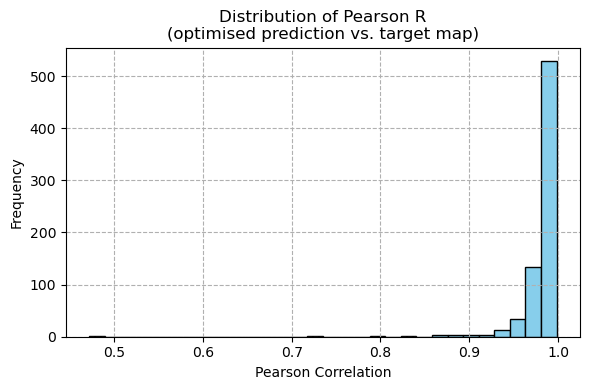

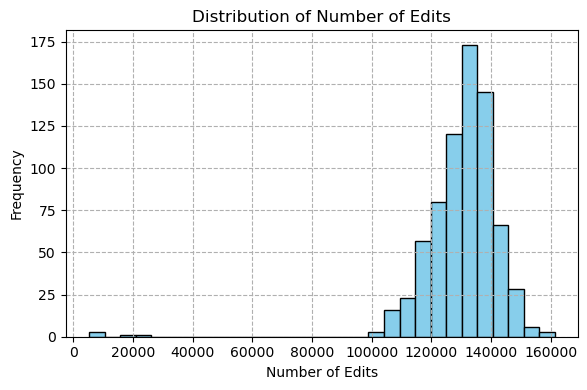

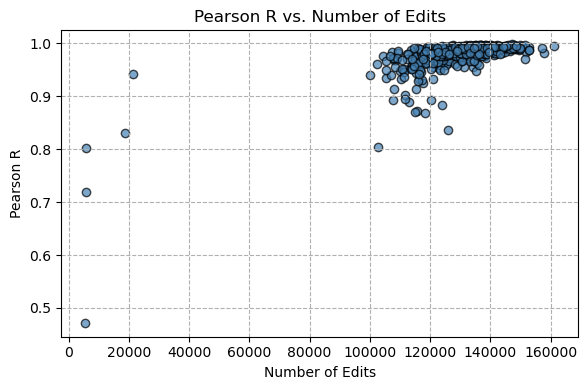

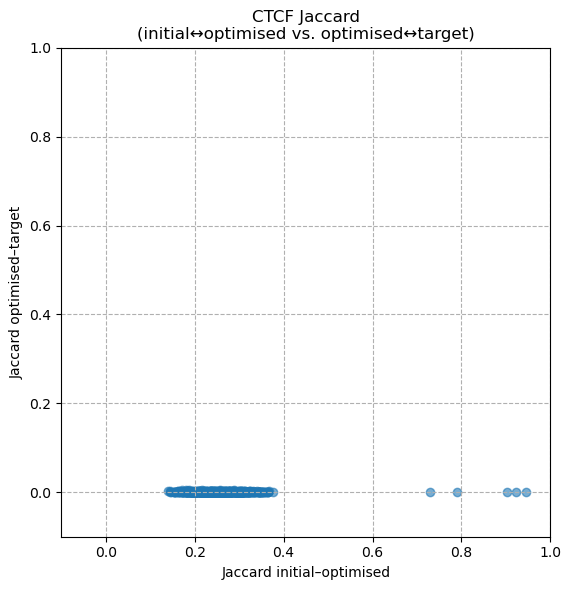

In [6]:
import matplotlib.pyplot as plt
import os

# 1. Pearson R distribution
plt.figure(figsize=(6, 4))
plt.hist(df["pearson_r"], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Pearson R\n(optimised prediction vs. target map)")
plt.xlabel("Pearson Correlation")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--')
plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, f"pearson_r_distribution_fold{FOLD}.svg")
plt.savefig(save_path, format="svg", bbox_inches="tight")
plt.show()

# 2. Edit count distribution
plt.figure(figsize=(6, 4))
plt.hist(df["edit_count"], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Number of Edits")
plt.xlabel("Number of Edits")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--')
plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, f"edit_count_distribution_fold{FOLD}.svg")
plt.savefig(save_path, format="svg", bbox_inches="tight")
plt.show()

# 3. Pearson R vs. edit count
plt.figure(figsize=(6, 4))
plt.scatter(df["edit_count"], df["pearson_r"], color="steelblue", edgecolor="black", alpha=0.7)
plt.title("Pearson R vs. Number of Edits")
plt.xlabel("Number of Edits")
plt.ylabel("Pearson R")
plt.grid(True, linestyle='--')
plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, f"pearson_vs_edits_fold{FOLD}.svg")
plt.savefig(save_path, format="svg", bbox_inches="tight")
plt.show()

# 4. Jaccard index scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(df["Jaccard_init_opt"], df["Jaccard_opt_target"], alpha=0.6)
plt.title("CTCF Jaccard\n(initial↔optimised vs. optimised↔target)")
plt.xlabel("Jaccard initial–optimised")
plt.ylabel("Jaccard optimised–target")

# Force axes to same scale between 0 and 1
plt.xlim(-0.1, 1)
plt.ylim(-0.1, 1)
plt.gca().set_aspect('equal', adjustable='box')  # keep square aspect ratio

plt.grid(True, linestyle='--')
plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, f"jaccard_index_fold{FOLD}.svg")
plt.savefig(save_path, format="svg", bbox_inches="tight")
plt.show()

## Save Enriched Results Table

In [ ]:
out_path = os.path.join(BASE_DIR, f"genomic_optimization_analysis_fold{FOLD}.tsv")
df.to_csv(out_path, sep="\t", index=False)
print(f"Saved: {out_path}")
df.head()